In [6]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Load and merge data

In [7]:
df1=pl.read_parquet(
    'items.parquet',
    columns=['item_id','category_l1','category_l2','category_l3','category'])
df2=pl.read_parquet(
    'transactions-202411-to-202412.parquet',
    columns=['updated_date', 'item_id', 'quantity']
)
df=df1.join(df2, on='item_id', how='left')
df=df.drop_nulls()
print(len(df))
print(df.head())

6053447
shape: (5, 7)
┌────────────────┬─────────────┬───────────────┬─────────────┬──────────┬───────────────┬──────────┐
│ item_id        ┆ category_l1 ┆ category_l2   ┆ category_l3 ┆ category ┆ updated_date  ┆ quantity │
│ ---            ┆ ---         ┆ ---           ┆ ---         ┆ ---      ┆ ---           ┆ ---      │
│ str            ┆ str         ┆ str           ┆ str         ┆ str      ┆ datetime[μs]  ┆ i32      │
╞════════════════╪═════════════╪═══════════════╪═════════════╪══════════╪═══════════════╪══════════╡
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-30    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 10:22:00.050  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty   ┆ 2024-12-28    ┆ 1        │
│                ┆             ┆ kiện          ┆             ┆ Pigeon   ┆ 13:39:11.750  ┆          │
│ 0007010000886  ┆ Babycare    ┆ Bình sữa, phụ ┆ Núm ty      ┆ Núm ty

# 2. Gom quantity theo week

In [8]:
import polars as pl

df = df.with_columns([
    pl.col("updated_date").cast(pl.Datetime).dt.month().alias("month"),
    pl.col("updated_date").cast(pl.Datetime).dt.day().alias("day")
]).with_columns(
    pl.when((pl.col("month") == 11) & (pl.col("day") <= 7)).then(1)
      .when((pl.col("month") == 11) & (pl.col("day") <= 14)).then(2)
      .when((pl.col("month") == 11) & (pl.col("day") <= 21)).then(3)
      .when((pl.col("month") == 11) & (pl.col("day") >= 22)).then(4)
      .when((pl.col("month") == 12) & (pl.col("day") <= 7)).then(5)
      .when((pl.col("month") == 12) & (pl.col("day") <= 14)).then(6)
      .when((pl.col("month") == 12) & (pl.col("day") <= 21)).then(7)
      .when((pl.col("month") == 12) & (pl.col("day") >= 22)).then(8)
      .otherwise(None).alias("week_id")
)

df = df.drop_nulls(subset=["week_id"]).drop(["month", "day"])

group_cols = ['item_id', 'category_l1', 'category_l2', 'category_l3', 'category', 'week_id']

df_grouped = df.group_by(group_cols).agg(
    pl.col("quantity").sum().alias("quantity")
)

df_final = df_grouped.with_columns(
    pl.when(pl.col("week_id") == 4).then(pl.col("quantity") / 9)
      .when(pl.col("week_id") == 8).then(pl.col("quantity") / 10)
      .otherwise(pl.col("quantity") / 7).alias("normalized_quantity")
)

df_final = df_final.drop("quantity")

df_final = df_final.sort(["item_id", "week_id"])

print(df_final.head())
df_final.write_parquet('ket_qua_kinh_doanh.parquet')

shape: (5, 7)
┌──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬─────────┬──────────────┐
│ item_id      ┆ category_l1  ┆ category_l2 ┆ category_l3  ┆ category     ┆ week_id ┆ normalized_q │
│ ---          ┆ ---          ┆ ---         ┆ ---          ┆ ---          ┆ ---     ┆ uantity      │
│ str          ┆ str          ┆ str         ┆ str          ┆ str          ┆ i32     ┆ ---          │
│              ┆              ┆             ┆              ┆              ┆         ┆ f64          │
╞══════════════╪══════════════╪═════════════╪══════════════╪══════════════╪═════════╪══════════════╡
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 1       ┆ 74.142857    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆         ┆              │
│ 000028000013 ┆ Đồ chơi &    ┆ 1Y+         ┆ Đồ chơi nước ┆ Đồ chơi nhà  ┆ 2       ┆ 74.571429    │
│ 8            ┆ Sách         ┆             ┆              ┆ tắm          ┆  

# 3. Visualize

## 3.1 Group by theo toàn bộ

shape: (8, 2)
┌─────────┬────────────────┐
│ week_id ┆ total_quantity │
│ ---     ┆ ---            │
│ i32     ┆ f64            │
╞═════════╪════════════════╡
│ 1       ┆ 151337.571429  │
│ 2       ┆ 170517.142857  │
│ 3       ┆ 141132.571429  │
│ 4       ┆ 168366.111111  │
│ 5       ┆ 151011.0       │
│ 6       ┆ 154340.428571  │
│ 7       ┆ 147385.857143  │
│ 8       ┆ 133586.4       │
└─────────┴────────────────┘


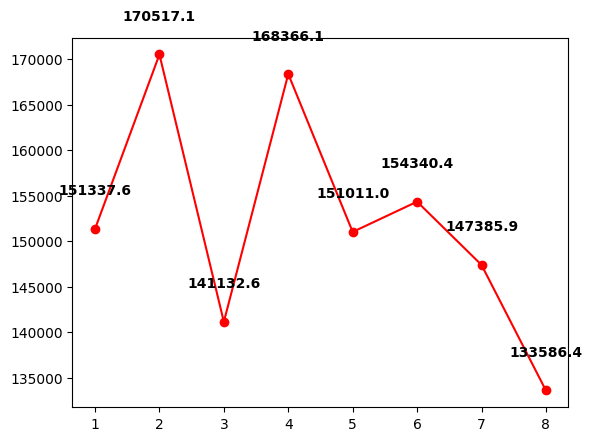

In [9]:
df_combo = df_final.group_by('week_id').agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_combo=df_combo.sort('week_id')
print(df_combo)

plt.plot(df_combo['week_id'], df_combo['total_quantity'], 'r', marker='o')
for x, y in zip(df_combo['week_id'], df_combo['total_quantity']):
        plt.text(x, y + (max(df_combo['total_quantity']) * 0.02), f"{y:.1f}",
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

## 3.2 Group by theo cat 1

In [10]:
df_cat1 = df_final.group_by(['category_l1', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat1=df_cat1.sort('week_id')
print(df_cat1.head())
print(len(df_cat1))

shape: (5, 3)
┌────────────────┬─────────┬────────────────┐
│ category_l1    ┆ week_id ┆ total_quantity │
│ ---            ┆ ---     ┆ ---            │
│ str            ┆ i32     ┆ f64            │
╞════════════════╪═════════╪════════════════╡
│ Đồ chơi & Sách ┆ 1       ┆ 1782.714286    │
│ Thời trang     ┆ 1       ┆ 6288.285714    │
│ Vệ sinh        ┆ 1       ┆ 8480.714286    │
│ Phụ kiện       ┆ 1       ┆ 1395.571429    │
│ Tã             ┆ 1       ┆ 11662.285714   │
└────────────────┴─────────┴────────────────┘
112


## 3.3 Group by theo cat 2

In [11]:
df_cat2 = df_final.group_by(['category_l2', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat2=df_cat2.sort('week_id')
print(df_cat2.head())
print(len(df_cat2))

shape: (5, 3)
┌──────────────────────────────┬─────────┬────────────────┐
│ category_l2                  ┆ week_id ┆ total_quantity │
│ ---                          ┆ ---     ┆ ---            │
│ str                          ┆ i32     ┆ f64            │
╞══════════════════════════════╪═════════╪════════════════╡
│ 1Y+                          ┆ 1       ┆ 963.714286     │
│ Gối                          ┆ 1       ┆ 366.0          │
│ Chăm sóc mẹ trước & sau sinh ┆ 1       ┆ 54.571429      │
│ Bé ngủ                       ┆ 1       ┆ 622.285714     │
│ Chăm sóc gia đình            ┆ 1       ┆ 547.571429     │
└──────────────────────────────┴─────────┴────────────────┘
912


## 3.4 Group by theo cat 3

In [12]:
df_cat3 = df_final.group_by(['category_l3', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat3=df_cat3.sort('week_id')
print(df_cat3.head())
print(len(df_cat3))

shape: (5, 3)
┌──────────────────────┬─────────┬────────────────┐
│ category_l3          ┆ week_id ┆ total_quantity │
│ ---                  ┆ ---     ┆ ---            │
│ str                  ┆ i32     ┆ f64            │
╞══════════════════════╪═════════╪════════════════╡
│ Đồ chơi nhồi bông    ┆ 1       ┆ 345.428571     │
│ Phụ kiện làm đẹp tồn ┆ 1       ┆ 48.142857      │
│ Chăm sóc dáng        ┆ 1       ┆ 3.285714       │
│ Khăn ướt vải         ┆ 1       ┆ 5165.428571    │
│ Khăn ướt bột giấy    ┆ 1       ┆ 650.857143     │
└──────────────────────┴─────────┴────────────────┘
3145


## 3.5 Group by theo category

In [13]:
df_cat = df_final.group_by(['category', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_cat=df_cat.sort('week_id')
print(df_cat.head())
print(len(df_cat))

shape: (5, 3)
┌─────────────────────────────┬─────────┬────────────────┐
│ category                    ┆ week_id ┆ total_quantity │
│ ---                         ┆ ---     ┆ ---            │
│ str                         ┆ i32     ┆ f64            │
╞═════════════════════════════╪═════════╪════════════════╡
│ Dụng cụ bảo vệ an toàn      ┆ 1       ┆ 4.571429       │
│ Dầu tràm Con Yêu            ┆ 1       ┆ 43.142857      │
│ Chăn xô, chăn Linen Animo   ┆ 1       ┆ 42.428571      │
│ Băng vệ sinh Diana sau sinh ┆ 1       ┆ 313.714286     │
│ Hipp                        ┆ 1       ┆ 464.142857     │
└─────────────────────────────┴─────────┴────────────────┘
9837


## 3.6 Group by theo item_id

In [14]:
df_item = df_final.group_by(['item_id', 'week_id']).agg(
    pl.col("normalized_quantity").sum().alias("total_quantity")
)

df_item=df_item.sort('week_id')
print(df_item.head())
print(len(df_item))

shape: (5, 3)
┌───────────────┬─────────┬────────────────┐
│ item_id       ┆ week_id ┆ total_quantity │
│ ---           ┆ ---     ┆ ---            │
│ str           ┆ i32     ┆ f64            │
╞═══════════════╪═════════╪════════════════╡
│ 0041000000017 ┆ 1       ┆ 1.857143       │
│ 0224000000005 ┆ 1       ┆ 0.285714       │
│ 2155000000009 ┆ 1       ┆ 0.142857       │
│ 0015020000051 ┆ 1       ┆ 0.142857       │
│ 3324000000310 ┆ 1       ┆ 0.285714       │
└───────────────┴─────────┴────────────────┘
79880


## 3.7 Plot theo item_id hoặc category

Cách truyền tham số vào hàm:
- Type = 0: plot theo category
- Type = 1: plot theo cat 1
- Type = 2: plot theo cat 2
- Type = 3: plot theo cat 3
- Type = 4: plot theo item_id

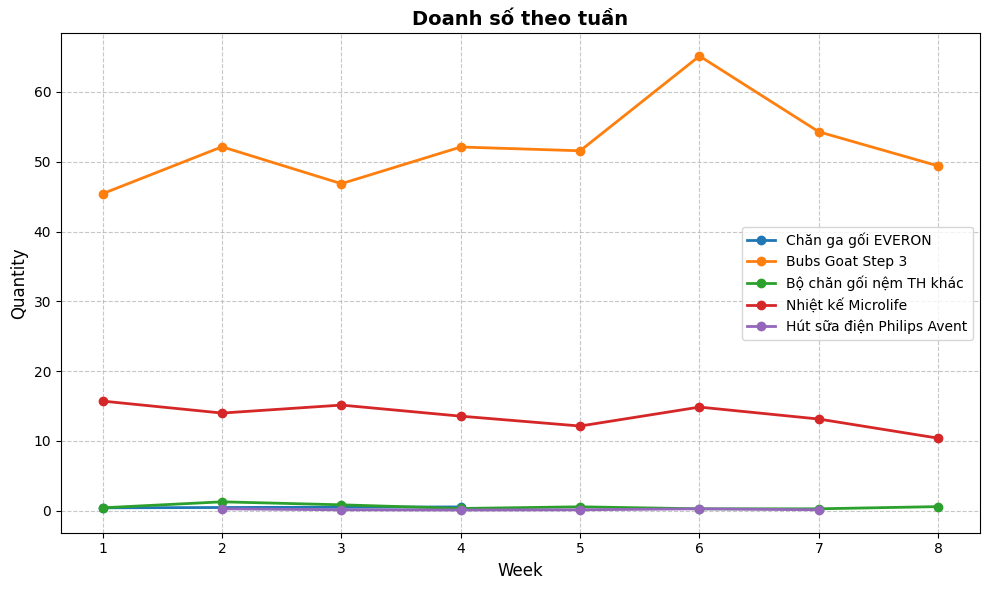

In [15]:
import random

def visualize(names=None, type=0, random_n=None):
    plt.figure(figsize=(10, 6))

    # 🔥 Chọn dataframe + column tương ứng
    if type == 0:
        df = df_cat
        col = "category"
    elif type == 1:
        df = df_cat1
        col = "category_l1"
    elif type == 2:
        df = df_cat2
        col = "category_l2"
    elif type == 3:
        df = df_cat3
        col = "category_l3"
    elif type == 4:
        df = df_item
        col = "item_id"

    # 🔥 Nếu không truyền names → random
    if names is None:
        unique_values = df.select(col).unique().to_series().to_list()
        if random_n is None:
            raise ValueError("Phải truyền random_n nếu names=None")
        names = random.sample(unique_values, min(random_n, len(unique_values)))

    for name in names:
        df_filtered = df.filter(pl.col(col) == name).sort("week_id")

        if df_filtered.height == 0:
            continue

        plt.plot(
            df_filtered['week_id'],
            df_filtered['total_quantity'],
            marker='o',
            linewidth=2,
            label=name
        )

        # annotate nếu ít line thôi
        if len(names) <= 3:
            for x, y in zip(df_filtered['week_id'], df_filtered['total_quantity']):
                plt.text(
                    x,
                    y,
                    f"{y:.1f}",
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    plt.title("Doanh số theo tuần", fontsize=14, fontweight='bold')
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Quantity", fontsize=12)

    plt.xticks([1,2,3,4,5,6,7,8])
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.legend()
    plt.tight_layout()
    plt.show()
visualize(
    names=None,
    type=0,
    random_n=5
)

# 4. Statistic

In [20]:
def process_by_total(df, holiday_week_id):
    weekly_df = (
        df.group_by("week_id")
        .agg(pl.col("normalized_quantity").sum().alias("total_quantity"))
        .sort("week_id")
    )

    non_holiday_mean = (
        weekly_df.filter(pl.col("week_id") != holiday_week_id)
        .select(pl.col("total_quantity").mean())
        .item()
    )

    holiday_value = (
        weekly_df.filter(pl.col("week_id") == holiday_week_id)
        .select("total_quantity")
        .item()
    )

    uplift = holiday_value - non_holiday_mean

    # 🔥 thêm dòng này
    pct_change = (uplift / non_holiday_mean) * 100 if non_holiday_mean != 0 else None

    result_df = pl.DataFrame({
        "mean_non_holiday_week": [non_holiday_mean],
        "holiday_week_value": [holiday_value],
        "uplift_vs_normal": [uplift],
        "pct_change_vs_normal": [pct_change]
    })

    print(result_df)
    return result_df

def process_by_category_level(df, holiday_week_id, type_cate):
    result = []

    min_week = df.select(pl.col("week_id").min()).item()
    max_week = df.select(pl.col("week_id").max()).item()

    full_weeks = pl.DataFrame({
        "week_id": list(range(min_week, max_week + 1))
    })

    category_values = (
        df.select(pl.col(type_cate).drop_nulls().unique())
        .to_series()
        .to_list()
    )

    for cate in category_values:
        cate_df = df.filter(pl.col(type_cate) == cate)

        weekly_sum = (
            cate_df.group_by("week_id")
            .agg(pl.col("normalized_quantity").sum().alias("total_quantity"))
        )

        weekly_df = (
            full_weeks.join(weekly_sum, on="week_id", how="left")
            .with_columns(pl.col("total_quantity").fill_null(0))
            .sort("week_id")
        )

        non_holiday_mean = (
            weekly_df.filter(pl.col("week_id") != holiday_week_id)
            .select(pl.col("total_quantity").mean())
            .item()
        )

        holiday_value = (
            weekly_df.filter(pl.col("week_id") == holiday_week_id)
            .select("total_quantity")
            .item()
        )

        uplift = holiday_value - non_holiday_mean

        # 🔥 thêm % change
        pct_change = (uplift / non_holiday_mean) * 100 if non_holiday_mean != 0 else None

        result.append({
            type_cate: cate,
            "mean_non_holiday_week": non_holiday_mean,
            "holiday_week_value": holiday_value,
            "uplift_vs_normal": uplift,
            "pct_change_vs_normal": pct_change
        })

    result = (
        pl.DataFrame(result)
        .sort("pct_change_vs_normal", descending=True, nulls_last=True)
    )

    print(result)
    return result

def process_statistic(df, holiday_week_id):
    total_stat_df = process_by_total(df, holiday_week_id)
    cat1_stat_df = process_by_category_level(df, holiday_week_id, "category_l1")
    cat2_stat_df = process_by_category_level(df, holiday_week_id, "category_l2")
    cat3_stat_df = process_by_category_level(df, holiday_week_id, "category_l3")
    cat_stat_df = process_by_category_level(df, holiday_week_id, "category")
    item_id_stat_df = process_by_category_level(df, holiday_week_id, "item_id")

    return {
        "total": total_stat_df,
        "cat1": cat1_stat_df,
        "cat2": cat2_stat_df,
        "cat3": cat3_stat_df,
        "category": cat_stat_df
    }


In [21]:
process_statistic(df_final, holiday_week_id=8)

shape: (1, 4)
┌───────────────────────┬────────────────────┬──────────────────┬──────────────────────┐
│ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal ┆ pct_change_vs_normal │
│ ---                   ┆ ---                ┆ ---              ┆ ---                  │
│ f64                   ┆ f64                ┆ f64              ┆ f64                  │
╞═══════════════════════╪════════════════════╪══════════════════╪══════════════════════╡
│ 154870.097506         ┆ 133586.4           ┆ -21283.697506    ┆ -13.742935           │
└───────────────────────┴────────────────────┴──────────────────┴──────────────────────┘
shape: (14, 5)
┌───────────────────┬───────────────────┬───────────────────┬──────────────────┬───────────────────┐
│ category_l1       ┆ mean_non_holiday_ ┆ holiday_week_valu ┆ uplift_vs_normal ┆ pct_change_vs_nor │
│ ---               ┆ week              ┆ e                 ┆ ---              ┆ mal               │
│ str               ┆ ---               ┆ ---

{'total': shape: (1, 4)
 ┌───────────────────────┬────────────────────┬──────────────────┬──────────────────────┐
 │ mean_non_holiday_week ┆ holiday_week_value ┆ uplift_vs_normal ┆ pct_change_vs_normal │
 │ ---                   ┆ ---                ┆ ---              ┆ ---                  │
 │ f64                   ┆ f64                ┆ f64              ┆ f64                  │
 ╞═══════════════════════╪════════════════════╪══════════════════╪══════════════════════╡
 │ 154870.097506         ┆ 133586.4           ┆ -21283.697506    ┆ -13.742935           │
 └───────────────────────┴────────────────────┴──────────────────┴──────────────────────┘,
 'cat1': shape: (14, 5)
 ┌───────────────────┬───────────────────┬───────────────────┬──────────────────┬───────────────────┐
 │ category_l1       ┆ mean_non_holiday_ ┆ holiday_week_valu ┆ uplift_vs_normal ┆ pct_change_vs_nor │
 │ ---               ┆ week              ┆ e                 ┆ ---              ┆ mal               │
 │ str         